# Solve LP

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import product as iterproduct
from pulp import LpStatus, value, constants


# ══════════════════════════════════════════════════════════════════════════════
# Internal helpers
# ══════════════════════════════════════════════════════════════════════════════

def _is_mip(model):
    return any(v.cat in (constants.LpInteger, constants.LpBinary)
               for v in model.variables())

def _is_binary(model):
    return all(v.cat == constants.LpBinary for v in model.variables())

def _get_coeffs(constraint, variables):
    """Return {var_name: coeff} dict and rhs b for a constraint."""
    coeffs = {v.name: constraint.get(v, 0) for v in variables}
    b = -constraint.constant
    return coeffs, b

def _constraint_mask_2d(constraint, x1_var, x2_var, X1, X2):
    a1 = constraint.get(x1_var, 0)
    a2 = constraint.get(x2_var, 0)
    b  = -constraint.constant
    lhs = a1 * X1 + a2 * X2
    if constraint.sense == -1: return lhs <= b + 1e-9
    if constraint.sense ==  1: return lhs >= b - 1e-9
    return np.abs(lhs - b) <= 1e-7

def _lp_binding(model):
    return [n for n, c in model.constraints.items()
            if c.slack is not None and abs(c.slack) < 1e-7]

def _lp_multiple_optima(model):
    def at_bound(v):
        val = value(v)
        if v.lowBound is not None and abs(val - v.lowBound) < 1e-7: return True
        if v.upBound  is not None and abs(val - v.upBound)  < 1e-7: return True
        return False
    has_var = any(v.dj is not None and abs(v.dj) < 1e-7 and at_bound(v)
                  for v in model.variables()
                  if v.lowBound is not None or v.upBound is not None)
    has_con = any(c.pi is not None and abs(c.pi) < 1e-7 and abs(c.slack) < 1e-7
                  for c in model.constraints.values())
    return has_var or has_con

def _mip_binding(model, variables):
    vals = {v.name: value(v) for v in variables}
    binding = []
    for name, c in model.constraints.items():
        coeffs, b = _get_coeffs(c, variables)
        lhs_val = sum(coeffs[v.name] * vals[v.name] for v in variables)
        slack = b - lhs_val if c.sense == -1 else lhs_val - b
        if abs(slack) < 1e-7:
            binding.append(name)
    return binding

def _eval_objective(model, variables, assignment):
    """Evaluate objective for a given dict {var_name: val}."""
    return sum(model.objective.get(v, 0) * assignment[v.name] for v in variables)

def _check_feasible(model, variables, assignment):
    """Check all constraints for a given assignment dict."""
    for c in model.constraints.values():
        lhs = sum(c.get(v, 0) * assignment[v.name] for v in variables)
        b   = -c.constant
        if c.sense == -1 and lhs > b + 1e-9: return False
        if c.sense ==  1 and lhs < b - 1e-9: return False
        if c.sense ==  0 and abs(lhs - b) > 1e-7: return False
    return True

def _enumerate_binary(model, variables):
    """Enumerate all 2^n binary combos; return list of (obj, assignment, feasible)."""
    n = len(variables)
    results = []
    for combo in iterproduct([0, 1], repeat=n):
        assignment = {variables[i].name: float(combo[i]) for i in range(n)}
        feas = _check_feasible(model, variables, assignment)
        obj  = _eval_objective(model, variables, assignment)
        results.append((obj, assignment, feas))
    return results


# ══════════════════════════════════════════════════════════════════════════════
# 2-variable plot (LP or MIP)
# ══════════════════════════════════════════════════════════════════════════════

def _plot_2d(model, variables, opt_x, opt_Z, mip,
             var_names, plot_range, n_points, iso_progression, figsize):

    x1_var, x2_var = variables
    lo, hi = plot_range
    x1_line = np.linspace(lo, hi, n_points)
    c1 = model.objective.get(x1_var, 0)
    c2 = model.objective.get(x2_var, 0)

    # Build grids
    X1c, X2c = np.meshgrid(x1_line, np.linspace(lo, hi, n_points))
    cont_masks = [X1c >= 0, X2c >= 0]

    if mip:
        i_vals = np.arange(int(np.floor(lo)), int(np.ceil(hi)) + 1, dtype=float)
        XI, YI = np.meshgrid(i_vals, i_vals)
        int_feas = (XI >= 0) & (YI >= 0)

    for constraint in model.constraints.values():
        cont_masks.append(_constraint_mask_2d(constraint, x1_var, x2_var, X1c, X2c))
        if mip:
            int_feas &= _constraint_mask_2d(constraint, x1_var, x2_var, XI, YI)

    cont_feasible = np.logical_and.reduce(cont_masks)

    fig, ax = plt.subplots(figsize=figsize)
    colors = ['blue', 'red', 'orange', 'brown', 'magenta', 'cyan', 'olive']
    cidx = 0

    for name, constraint in model.constraints.items():
        a1 = constraint.get(x1_var, 0)
        a2 = constraint.get(x2_var, 0)
        b  = -constraint.constant
        if (a1 == 0) != (a2 == 0) and b == 0:
            cidx += 1; continue
        sense_str = {-1: r'\leq', 0: '=', 1: r'\geq'}[constraint.sense]
        parts = ([f'{a1:g}{var_names[0]}'] if a1 else []) + \
                ([f'{a2:g}{var_names[1]}'] if a2 else [])
        label = f'${"+ ".join(parts)} {sense_str} {b:g}$ ({name})'
        color = colors[cidx % len(colors)]
        if a2 != 0:
            ax.plot(x1_line, (b - a1 * x1_line) / a2, label=label, color=color, lw=2)
        elif a1 != 0:
            ax.axvline(b / a1, label=label, color=color, lw=2)
        cidx += 1

    ax.contourf(X1c, X2c, cont_feasible.astype(int),
                levels=[0.5, 1.5], colors=['green'], alpha=0.20)
    ax.fill_between([], [], [], color='green', alpha=0.20,
                    label='Feasible Region' + (' (LP relaxation)' if mip else ''))

    if mip:
        Z_int = c1 * XI + c2 * YI
        non_opt = int_feas & (np.abs(Z_int - opt_Z) >= 1e-6)
        opt_int = int_feas & (np.abs(Z_int - opt_Z)  < 1e-6)
        ax.scatter(XI[non_opt], YI[non_opt], color='green', s=25, zorder=4, alpha=0.6,
                   label='Feasible integer points')
        if np.any(opt_int):
            ax.scatter(XI[opt_int], YI[opt_int], color='gold', edgecolors='black',
                       s=80, zorder=5, label=f'Optimal Z={opt_Z:g}')

    if iso_progression is None:
        iso_progression = [round(opt_Z * 0.3, 2), round(opt_Z * 0.6, 2)]
    if c2 != 0:
        for z_val, style, alpha in [(z, ':', 0.4) for z in iso_progression] + [(opt_Z, '-', 1.0)]:
            ax.plot(x1_line, (z_val - c1 * x1_line) / c2,
                    linestyle=style, color='purple', alpha=alpha,
                    label=f'Isoquant Z={z_val:g}' if z_val == opt_Z else None)

    marker, msize = ('*', 14) if mip else ('o', 8)
    ax.plot(opt_x[var_names[0]], opt_x[var_names[1]],
            marker=marker, color='black', markersize=msize, zorder=6)
    offset = (hi - lo) * 0.06
    ax.annotate(f'Optimal\n({opt_x[var_names[0]]:g}, {opt_x[var_names[1]]:g})\nZ={opt_Z:g}',
                xy=(opt_x[var_names[0]], opt_x[var_names[1]]),
                xytext=(opt_x[var_names[0]] + offset, opt_x[var_names[1]] + offset),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                fontsize=9)

    ax.set_xlim(lo, hi * 0.9); ax.set_ylim(lo, hi * 0.9)
    ax.set_xlabel(f'${var_names[0]}$', fontsize=12)
    ax.set_ylabel(f'${var_names[1]}$', fontsize=12)
    ptype = "Integer Programming (MIP)" if mip else "Linear Programming (LP)"
    ax.set_title(f'{ptype}: Feasible Region, Constraints & Isoquants', fontsize=13)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)
    if mip:
        ax.set_xticks(np.arange(int(lo), int(hi * 0.9) + 1))
        ax.set_yticks(np.arange(int(lo), int(hi * 0.9) + 1))
    plt.tight_layout(); plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Multi-variable MIP plot (3+ variables)
# ══════════════════════════════════════════════════════════════════════════════

def _plot_mip_nd(model, variables, var_names, opt_x, opt_Z, figsize):
    """
    Three-panel dashboard for n-variable binary/integer MIP:
      Panel 1 — Solution landscape: objective value of every feasible combo,
                 sorted descending, optimal highlighted.
      Panel 2 — Variable contribution to the optimal objective.
      Panel 3 — Constraint utilisation at the optimal solution.
    """
    n_vars = len(variables)
    binary = _is_binary(model)

    # ── enumerate (binary) or skip enumeration (general integer) ──────────────
    if binary and n_vars <= 20:
        all_results = _enumerate_binary(model, variables)
        feasible_results = sorted(
            [(obj, asgn) for obj, asgn, feas in all_results if feas],
            reverse=(model.sense == -1 or True)   # descending by obj
        )
        # For maximisation sort descending; minimisation ascending
        if model.sense == 1:   # LpMinimize == 1
            feasible_results.sort(key=lambda x: x[0])
        else:
            feasible_results.sort(key=lambda x: x[0], reverse=True)
    else:
        feasible_results = None   # skip landscape panel for large/general MIP

    # ── figure layout ─────────────────────────────────────────────────────────
    has_landscape = feasible_results is not None
    n_panels = 3 if has_landscape else 2
    fig, axes = plt.subplots(1, n_panels,
                             figsize=(figsize[0] * n_panels / 2, figsize[1] * 0.7))
    if n_panels == 1:
        axes = [axes]

    panel = 0   # rolling panel index

    # ── Panel 1: Solution landscape ───────────────────────────────────────────
    if has_landscape:
        ax = axes[panel]; panel += 1
        objs = [r[0] for r in feasible_results]
        n_feas = len(objs)

        bar_colors = []
        for obj, asgn in feasible_results:
            if abs(obj - opt_Z) < 1e-6:
                bar_colors.append('#f4c542')   # gold = optimal
            else:
                bar_colors.append('#4c9be8')   # blue = feasible

        bars = ax.bar(range(n_feas), objs, color=bar_colors,
                      edgecolor='black', linewidth=0.5)

        # Label bars with their combo string
        for i, (obj, asgn) in enumerate(feasible_results):
            combo_str = '(' + ', '.join(f'{int(asgn[vn]):g}' for vn in var_names) + ')'
            ax.text(i, obj + max(objs) * 0.01, combo_str,
                    ha='center', va='bottom', fontsize=6.5, rotation=45)

        ax.set_xticks(range(n_feas))
        ax.set_xticklabels([str(i + 1) for i in range(n_feas)], fontsize=8)
        ax.set_xlabel('Feasible Combinations (ranked by objective)', fontsize=9)
        ax.set_ylabel('Objective Value Z', fontsize=9)
        ax.set_title(f'Solution Landscape\n({n_feas} feasible of {2**n_vars} total)', fontsize=10)
        ax.set_ylim(0, max(objs) * 1.20)
        ax.grid(axis='y', linestyle='--', alpha=0.4)

        gold_patch = mpatches.Patch(color='#f4c542', label=f'Optimal Z={opt_Z:g}')
        blue_patch = mpatches.Patch(color='#4c9be8', label='Feasible')
        ax.legend(handles=[gold_patch, blue_patch], fontsize=8)

    # ── Panel 2: Variable contribution at optimal ─────────────────────────────
    ax = axes[panel]; panel += 1
    contrib = {}
    for v in variables:
        coeff = model.objective.get(v, 0)
        contrib[v.name] = coeff * opt_x[v.name]

    names  = [v.name for v in variables]
    values_contrib = [contrib[n] for n in names]
    selected = [opt_x[n] > 0.5 for n in names]   # True if included in solution

    bar_colors2 = ['#2ecc71' if s else '#e0e0e0' for s in selected]
    bars2 = ax.bar(names, values_contrib, color=bar_colors2,
                   edgecolor='black', linewidth=0.6)

    for bar, val, sel in zip(bars2, values_contrib, selected):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(values_contrib) * 0.01,
                    f'{val:g}', ha='center', va='bottom', fontsize=9,
                    fontweight='bold' if sel else 'normal')

    ax.set_xlabel('Variable', fontsize=9)
    ax.set_ylabel('Contribution to Z', fontsize=9)
    ax.set_title(f'Optimal Solution  Z={opt_Z:g}\n'
                 f'({", ".join(n for n, s in zip(names, selected) if s)} selected)',
                 fontsize=10)
    ax.set_ylim(0, max(values_contrib) * 1.25 if max(values_contrib) > 0 else 1)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    in_patch  = mpatches.Patch(color='#2ecc71', label='Included in solution')
    out_patch = mpatches.Patch(color='#e0e0e0', label='Not selected')
    ax.legend(handles=[in_patch, out_patch], fontsize=8)

    # ── Panel 3: Constraint utilisation ───────────────────────────────────────
    ax = axes[panel]; panel += 1
    con_names, used_pcts, rhs_vals, used_vals = [], [], [], []

    for cname, c in model.constraints.items():
        coeffs, b = _get_coeffs(c, variables)
        lhs_val = sum(coeffs[v.name] * opt_x[v.name] for v in variables)
        if b == 0:
            continue
        pct = abs(lhs_val / b) * 100
        con_names.append(cname)
        used_pcts.append(min(pct, 100))   # cap at 100 for display
        rhs_vals.append(b)
        used_vals.append(lhs_val)

    if con_names:
        bar_colors3 = []
        for pct in used_pcts:
            if pct >= 99.9:  bar_colors3.append('#e74c3c')   # red = binding
            elif pct >= 75:  bar_colors3.append('#f39c12')   # orange = tight
            else:            bar_colors3.append('#3498db')   # blue = slack

        bars3 = ax.barh(con_names, used_pcts, color=bar_colors3,
                        edgecolor='black', linewidth=0.6)
        ax.axvline(100, color='black', lw=1.5, linestyle='--', label='Capacity (100%)')

        for bar, pct, uv, rv in zip(bars3, used_pcts, used_vals, rhs_vals):
            ax.text(min(pct + 1, 101), bar.get_y() + bar.get_height() / 2,
                    f'{uv:g} / {rv:g}  ({pct:.1f}%)',
                    va='center', fontsize=9)

        ax.set_xlim(0, 130)
        ax.set_xlabel('Utilisation (%)', fontsize=9)
        ax.set_title('Constraint Utilisation\nat Optimal Solution', fontsize=10)
        ax.grid(axis='x', linestyle='--', alpha=0.4)

        red_p   = mpatches.Patch(color='#e74c3c', label='Binding (100%)')
        ora_p   = mpatches.Patch(color='#f39c12', label='Tight (≥75%)')
        blue_p  = mpatches.Patch(color='#3498db', label='Slack (<75%)')
        ax.legend(handles=[red_p, ora_p, blue_p], fontsize=8, loc='lower right')

    ptype = "Binary IP" if binary else "MIP"
    fig.suptitle(f'{ptype} Analysis  —  {n_vars} Variables, '
                 f'{len(model.constraints)} Constraints',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Public entry point
# ══════════════════════════════════════════════════════════════════════════════

def analyze_lp(model, var_names=None, plot_range=(0, 20), n_points=400,
               iso_progression=None, figsize=(10, 10)):
    """
    Solve and analyse a PuLP LP or MIP of any number of variables.

    • 2 variables  → feasible-region + isoquant plot (same as before).
    • 3+ variables → three-panel MIP dashboard:
        - Solution landscape (all feasible combos ranked, binary only ≤20 vars)
        - Variable contribution bar chart
        - Constraint utilisation chart

    Parameters
    ----------
    model        : pulp.LpProblem  (objective + constraints already added)
    var_names    : tuple[str] or None  — variable names in the model;
                   if None, inferred from model.variables() in declaration order
    plot_range   : (float, float)  — axis limits for 2D plot only
    n_points     : int             — grid resolution for 2D plot only
    iso_progression : list[float] or None  — extra isoquant Z values (2D only)
    figsize      : (float, float)
    """
    mip = _is_mip(model)

    # ── 1. Solve ──────────────────────────────────────────────────────────────
    model.solve()
    status_label = LpStatus[model.status]

    # ── 2. Resolve variable order ─────────────────────────────────────────────
    var_dict = {v.name: v for v in model.variables()}
    if var_names is None:
        var_names = tuple(v.name for v in model.variables())
    variables = [var_dict[n] for n in var_names]

    opt_x = {n: value(var_dict[n]) for n in var_names}
    opt_Z = value(model.objective)

    # ── 3. Status ─────────────────────────────────────────────────────────────
    if status_label == "Optimal":
        if mip and _is_binary(model) and len(variables) <= 20:
            # Use full enumeration for multiple-optima check
            all_results = _enumerate_binary(model, variables)
            opt_count = sum(1 for obj, _, feas in all_results
                            if feas and abs(obj - opt_Z) < 1e-6)
            has_multiple = opt_count > 1
        elif mip:
            has_multiple = False   # can't enumerate; assume unique
        else:
            has_multiple = _lp_multiple_optima(model)
        output_status = "Optimal, multiple solutions" if has_multiple else "Optimal, unique solution"
    else:
        output_status = status_label

    # ── 4. Console output ─────────────────────────────────────────────────────
    problem_type = ("Binary IP" if mip and _is_binary(model)
                    else "MIP" if mip else "LP")
    print(f"[{problem_type}] Status: {output_status}")

    if status_label != "Optimal":
        print("No optimal solution to report.")
        return

    sol_str = ",  ".join(f"{n} = {opt_x[n]:g}" for n in var_names)
    print(f"Z = {opt_Z:g},  {sol_str}")

    print("\nBinding Constraints:")
    binding = _mip_binding(model, variables) if mip else _lp_binding(model)
    if binding:
        for name in binding: print(f"  - {name}")
    else:
        print("  (none)")

    # ── 5. Plot ───────────────────────────────────────────────────────────────
    if len(variables) == 2:
        _plot_2d(model, variables, opt_x, opt_Z, mip,
                 var_names, plot_range, n_points, iso_progression, figsize)
    else:
        _plot_mip_nd(model, variables, var_names, opt_x, opt_Z, figsize)

[MIP] Status: Optimal, unique solution
Z = 30,  x0 = 0,  x1 = 1,  x2 = 0,  x3 = 1

Binding Constraints:
  - Hours


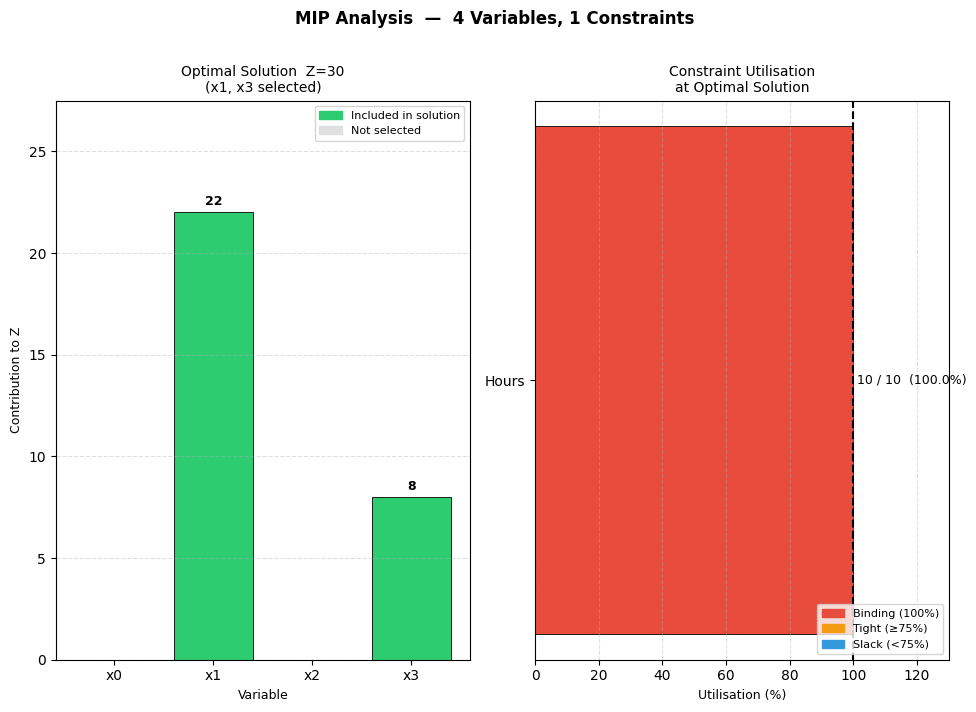

In [8]:
from pulp import LpProblem, LpMaximize, LpVariable

model = LpProblem("Maximization_Problem", LpMaximize)
 
# No lowBound — variables are free; non-negativity added as constraints below
w = [5, 7, 4, 3]
v = [16, 22, 12, 8]

xwv = {f'x{i}': {
        'x': LpVariable(f"x{i}", cat='Binary'),
        'w': w[i],
        'v': v[i]
    }  for i in range(0,4)
}


 
model += sum(v['x']*v['v'] for v in xwv.values()), "Objective"
model += sum(v['x']*v['w'] for v in xwv.values()) <= 10, "Hours"

 
analyze_lp(model, var_names=tuple(xwv.keys()), plot_range=(0, 15))